# Area calculation of a curve using trapezoidal rule

Importing Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import time
from typing import Callable


Python implementation of the algorithm



In [13]:
def py_trapz(f: Callable[[float], float], a: float, b: float, n: int) -> float:
    """
    Optimized pure Python implementation of trapezoidal rule integration.
    Uses memory-efficient iteration and minimal function calls.
    
    Args:
        f: Function to integrate
        a: Lower bound
        b: Upper bound
        n: Number of intervals
    
    Returns:
        Approximation of the integral of f from a to b using the trapezoidal rule.
    """
    if n <= 0:
        raise ValueError("Number of intervals must be positive")
    
    h = (b - a) / n
    total_area = 0
    
    x = a
    for i in range(1, n):
        x += h
        total_area += f(x)
    
    return h * total_area

Numpy Implementation of the algorithm


In [14]:
def np_trapz(f: Callable[[float], float], a: float, b: float, n: int) -> float:
    """
    NumPy implementation of trapezoidal integration.
    
    Args:
        f: Function to integrate
        a: Lower bound
        b: Upper bound
        n: Number of intervals
    
    Returns:
        Approximation of the integral of f from a to b using the trapezoidal rule.
    """
    x = np.linspace(a, b, n)
    y = f(x)
    return np.trapz(y, x)

Cython Implementation of the algorithm.
(The code is tested in the same cell)

```python

In [15]:
%pip install cython
%reload_ext Cython

Note: you may need to restart the kernel to use updated packages.


In [16]:
%%cython --annotate

import cython
import time
from libc.math cimport sin, exp, abs
from math import pi

@cython.boundscheck(False)
@cython.wraparound(False)
@cython.cdivision(True)
def cy_trapz(f, double a, double b, int n):
    """
    Optimized Cython implementation of trapezoidal rule integration.
    
    Args:
        f: Function to integrate (must be a C function pointer)
        a: Lower bound
        b: Upper bound
        n: Number of intervals
    
    Returns:
        Approximation of the integral of f from a to b using the trapezoidal rule.
    """
    if n <= 0:
        raise ValueError("Number of intervals must be positive")
    
    cdef:
        double h = (b - a) / n
        double total_area = 0.0
        int i
        double x
    
    total_area = (f(a) + f(b)) / 2.0
    
    for i in range(1, n):
        x = a + i * h
        total_area += f(x)
    
    return h * total_area


cdef double c_square(double x):
    return x * x

cdef double c_sin(double x):
    return sin(x)

cdef double c_exp(double x):
    return exp(x)

cdef invert(double x):
    return 1.0 / x

# Python wrapper for testing
def test_integration(f,a,b,n):
    start = time.time()
    result = cy_trapz(f, a, b, n)
    end = time.time()
    print(f"\nIntegral : {result:.6f}")
    print(f"\nTime taken: {end - start:.6f} seconds")

test_integration(c_sin, 0, pi, 10000000)



Displaying the curve and the trapezoids

```python

In [17]:
def visualize_trapz(f: Callable[[float], float], a: float, b: float, n: int):
    """
    Visualize the trapezoidal rule integration with interval lines.
    
    Args:
        f: Function to integrate
        a: Lower bound
        b: Upper bound
        n: Number of intervals
    """
    x = [a + i * (b - a) / n for i in range(n + 1)]
    y = [f(xi) for xi in x]
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b', label='f(x)', linewidth=2)
    
    for i in range(n):
        xs = [x[i], x[i], x[i+1], x[i+1]]
        ys = [0, y[i], y[i+1], 0]
        plt.fill(xs, ys, 'r', alpha=0.1)
        plt.vlines(x[i], 0, y[i], colors='gray', linestyles='dotted')
    
    plt.vlines(x[-1], 0, y[-1], colors='gray', linestyles='dotted')
    plt.title('Trapezoidal Rule Integration')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [18]:
def f1(x: float) -> float:
    return x * x

def f2(x: float) -> float:
    return math.sin(x)

def f3(x: float) -> float:
    return math.exp(x)

def f4(x: float) -> float:
    return 1.0 / x if x != 0 else float('inf')

Calculating the time taken by each implementation

```python

In [19]:
def time_trapz(func: Callable[[Callable[[float], float], float, float, int], float], f: Callable[[float], float], a: float, b: float, n: int) -> float:
    """
    Compare performance of different implementations.
    
    Args:
        f: Function to integrate
        a: Lower bound
        b: Upper bound
        n: Number of intervals
        runs: Number of runs to average the timing
    """
    start = time.time()
    result = func(f, a, b, n)
    end = time.time()
    elapsed = end - start
    print(f"Integral: {result:.6f}")
    print(f"Time taken: {elapsed:.6f} seconds")

Testing the implementation

```python

Analytical solution: 333.3333333333333

Performance Comparison:

Pure Python:
Integral: 333.333283
Time taken: 0.873904 seconds

NumPy:
Integral: 333.333333
Time taken: 0.133248 seconds

Generating visualization...


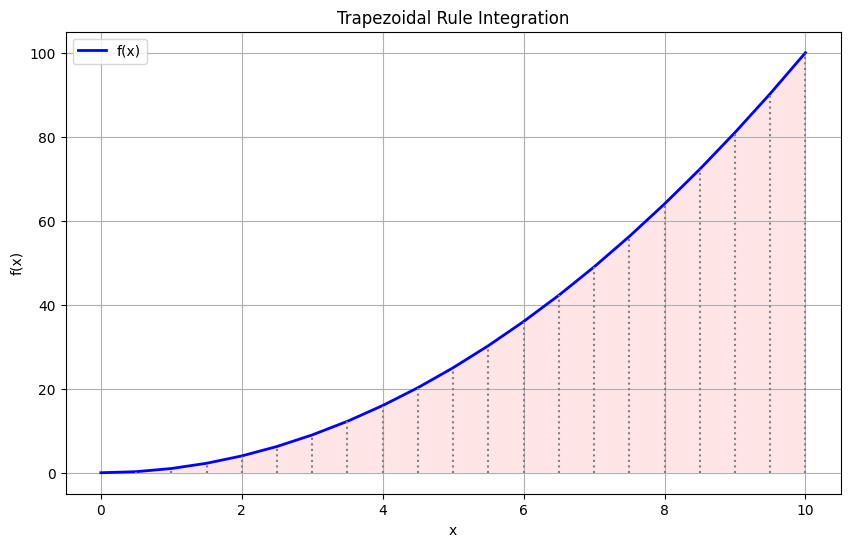

In [20]:

if __name__ == "__main__":
    a, b = 0, 10
    n = 10000000
    analytical = 1/3 * (b**3 - a**3)
    print(f"Analytical solution: {analytical}")
    print("\nPerformance Comparison:")
    print("=======================")
    print("\nPure Python:")
    time_trapz(py_trapz,f1, a, b, n)
    print("\nNumPy:")   
    time_trapz(np_trapz,f1, a, b, n)    
    print("\nGenerating visualization...")
    visualize_trapz(f1, a, b, 20)

Analytical solution: 2

Performance Comparison:

Pure Python:
Integral: 2.000000
Time taken: 1.445185 seconds

NumPy:
Integral: 2.000000
Time taken: 0.168733 seconds

Generating visualization...


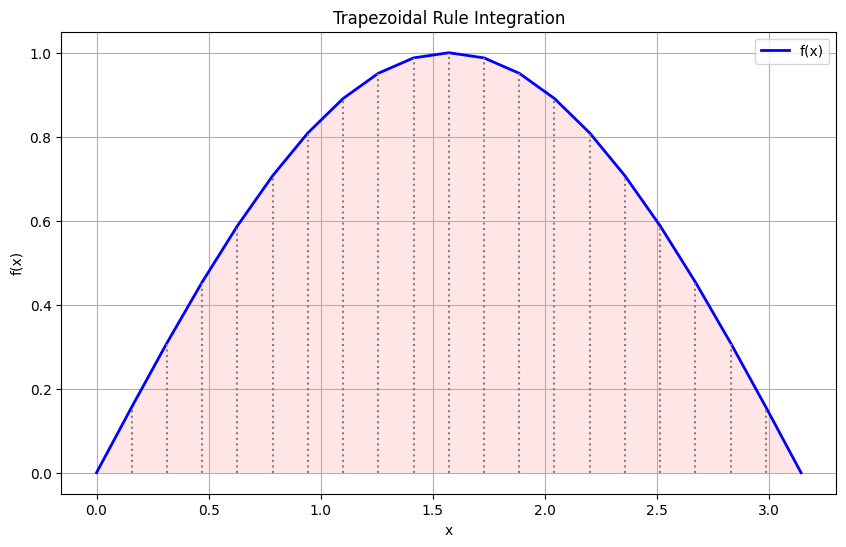

In [21]:
if __name__ == "__main__":
    a, b = 0, pi
    n = 10000000
    analytical = 2
    print(f"Analytical solution: {analytical}")
    print("\nPerformance Comparison:")
    print("=======================")
    print("\nPure Python:")
    time_trapz(py_trapz,f2, a, b, n)
    print("\nNumPy:")   
    time_trapz(np_trapz,np.sin, a, b, n)    
    print("\nGenerating visualization...")
    visualize_trapz(f2, a, b, 20)